In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

PATH_DATA_MONTERREY = "../data_municipios/serie_trimestral_monterrey.csv"
mont = pd.read_csv(PATH_DATA_MONTERREY)
mont["fecha"] = pd.to_datetime(mont["fecha"], format="%Y-%m-%d")
mont["log_pib_mun"] = np.log(mont["pib_mun"])
mont["log_Suma_de_radianza_mean"] = np.log(mont["Suma_de_radianza_mean"])
mont.head()

,quarter,total_pixeles_median,Suma_de_radianza_sum,Suma_de_radianza_median,Suma_de_radianza_std,Suma_de_radianza_mean,Media_de_radianza_mean,Desviacion_estandar_de_radianza_mean,Maximo_de_radianza_max,Minimo_de_radianza_min,Percentil_25_de_radianza_mean,Percentil_50_de_radianza_mean,Percentil_75_de_radianza_mean,fecha,municipio,pib_mun_desestacionalizado,pib_mun,log_pib_mun,log_Suma_de_radianza_mean
0,2012Q1,944.0,2.260189e+07,337375.753472,451.067987,337341.631003,357.353423,166.799462,1082.038090,30.090319,259.641051,371.544162,458.183951,2012-03-31,Monterrey,203192.860438,204466.270111,12.228158,12.728851
1,2012Q2,944.0,3.047335e+07,338642.789166,259.887249,338592.733717,358.678743,168.284067,1140.841299,28.843527,261.939875,373.011865,459.078295,2012-06-30,Monterrey,204988.836490,204568.792993,12.228660,12.732553
2,2012Q3,944.0,3.118174e+07,338959.064239,66.057983,338931.904762,359.038035,169.275790,1190.862719,27.716814,263.634534,373.418013,458.602275,2012-09-30,Monterrey,204827.521210,204352.360784,12.227601,12.733554
3,2012Q4,944.0,3.110918e+07,338243.533017,464.394446,338143.244627,358.202590,169.565194,1233.661195,26.806686,264.377011,372.544959,456.587347,2012-12-31,Monterrey,204462.581361,204241.417710,12.227058,12.731225
4,2013Q1,944.0,2.990186e+07,332341.277518,3123.726081,332242.919336,351.952245,166.808255,1236.262385,26.777189,260.491782,365.789117,447.746867,2013-03-31,Monterrey,203137.268196,203998.854231,12.225870,12.713622


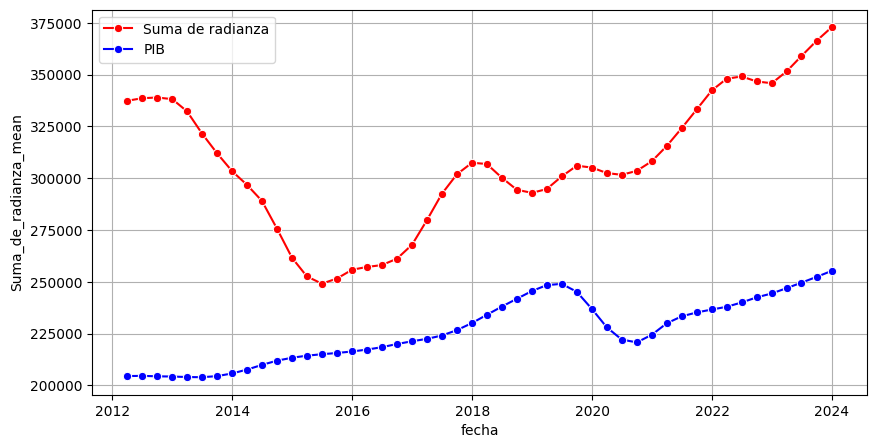

In [75]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="fecha", y="Suma_de_radianza_mean", data=mont, color = "red", label = "Suma de radianza", marker = "o")
sns.lineplot(x="fecha", y="pib_mun", data=mont, color = "blue", label = "PIB", marker = "o")
plt.legend()
plt.grid(True)
plt.show()

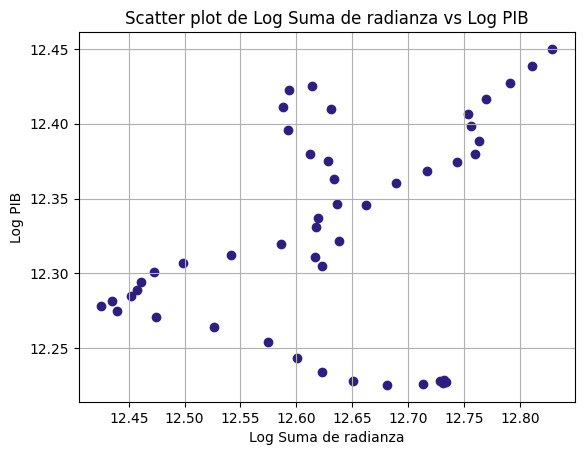

In [76]:
plt.scatter(mont["log_Suma_de_radianza_mean"], mont["log_pib_mun"], color = "#301D82")
plt.title("Scatter plot de Log Suma de radianza vs Log PIB")
plt.xlabel("Log Suma de radianza")
plt.ylabel("Log PIB")
plt.grid(True)
plt.show()


# Minimos cuadrados ordinarios

In [77]:
mont.head()

,quarter,total_pixeles_median,Suma_de_radianza_sum,Suma_de_radianza_median,Suma_de_radianza_std,Suma_de_radianza_mean,Media_de_radianza_mean,Desviacion_estandar_de_radianza_mean,Maximo_de_radianza_max,Minimo_de_radianza_min,Percentil_25_de_radianza_mean,Percentil_50_de_radianza_mean,Percentil_75_de_radianza_mean,fecha,municipio,pib_mun_desestacionalizado,pib_mun,log_pib_mun,log_Suma_de_radianza_mean
0,2012Q1,944.0,2.260189e+07,337375.753472,451.067987,337341.631003,357.353423,166.799462,1082.038090,30.090319,259.641051,371.544162,458.183951,2012-03-31,Monterrey,203192.860438,204466.270111,12.228158,12.728851
1,2012Q2,944.0,3.047335e+07,338642.789166,259.887249,338592.733717,358.678743,168.284067,1140.841299,28.843527,261.939875,373.011865,459.078295,2012-06-30,Monterrey,204988.836490,204568.792993,12.228660,12.732553
2,2012Q3,944.0,3.118174e+07,338959.064239,66.057983,338931.904762,359.038035,169.275790,1190.862719,27.716814,263.634534,373.418013,458.602275,2012-09-30,Monterrey,204827.521210,204352.360784,12.227601,12.733554
3,2012Q4,944.0,3.110918e+07,338243.533017,464.394446,338143.244627,358.202590,169.565194,1233.661195,26.806686,264.377011,372.544959,456.587347,2012-12-31,Monterrey,204462.581361,204241.417710,12.227058,12.731225
4,2013Q1,944.0,2.990186e+07,332341.277518,3123.726081,332242.919336,351.952245,166.808255,1236.262385,26.777189,260.491782,365.789117,447.746867,2013-03-31,Monterrey,203137.268196,203998.854231,12.225870,12.713622


                            OLS Regression Results                            
Dep. Variable:            log_pib_mun   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     51.52
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           1.31e-18
Time:                        22:52:31   Log-Likelihood:                 130.88
No. Observations:                  48   AIC:                            -235.8
Df Residuals:                      35   BIC:                            -211.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


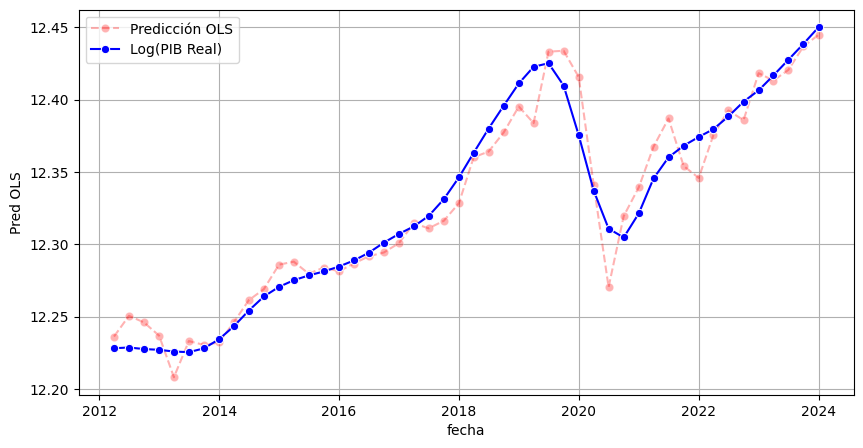

In [78]:

# Añadir una constante al modelo
X = mont.drop(columns = ["quarter", "fecha", "log_pib_mun", "municipio", "pib_mun"])
y = mont["log_pib_mun"]

X = sm.add_constant(X)
modelo = sm.OLS(y, X)
resultado = modelo.fit()

print(resultado.summary())

mont["Pred OLS"] = resultado.predict(X)

plt.figure(figsize=(10, 5))
sns.lineplot(x="fecha", y="Pred OLS", data=mont, color = "red", label = "Predicción OLS", marker = "o", linestyle = "--", alpha = 0.3)
sns.lineplot(x="fecha", y="log_pib_mun", data=mont, color = "blue", label = "Log(PIB Real)", marker = "o")
plt.legend()
plt.grid(True)
plt.show()



In [79]:
import sys
sys.path.append("..")

from utils.preprocessing import preprocessing_completo
from utils.config import PATH_RAD_MUNICIPIOS, PATH_PIB_MONTERREY

_,_,mont_rad_pib = preprocessing_completo("monterrey", path_radianza = PATH_RAD_MUNICIPIOS, path_pib = PATH_PIB_MONTERREY)

INICIANDO PREPROCESAMIENTO PARA: MONTERREY
📂 Archivo de radianza: ../data_municipios/municipios_completos.csv
📂 Archivo de PIB: ../data_municipios/serie_PIB_mty.csv

1️⃣  Cargando datos de radianza para monterrey...
   ✓ Datos cargados: 4672 registros

2️⃣  Removiendo outliers...
   ✓ Outliers removidos: 4670 registros restantes
   ✓ Medidas identificadas: 8 columnas

3️⃣  Aplicando STL a datos de radianza...
   ✓ STL aplicado a 8 medidas

4️⃣  Procesando datos de PIB...
   ✓ PIB procesado: 80 registros

5️⃣  Agregando radianza a nivel trimestral...
   ✓ Datos agregados: 52 trimestres

6️⃣  Uniendo datos de PIB y radianza...
   ✓ Datos unidos: 48 registros trimestrales

💾 Radianza trend guardado en: ../data_municipios/monterrey_trend.csv
💾 PIB trend guardado en: ../data_municipios/pib_trend_mon.csv
💾 Datos merged guardados en: ../data_municipios/serie_trimestral_monterrey.csv

✅ PREPROCESAMIENTO COMPLETADO EXITOSAMENTE

📊 Resumen de resultados para MONTERREY:
   • Radianza trend: 4670 

                            OLS Regression Results                            
Dep. Variable:                pib_mun   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     13.13
Date:                Sat, 01 Nov 2025   Prob (F-statistic):           2.14e-09
Time:                        22:52:38   Log-Likelihood:                -494.84
No. Observations:                  48   AIC:                             1012.
Df Residuals:                      37   BIC:                             1032.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


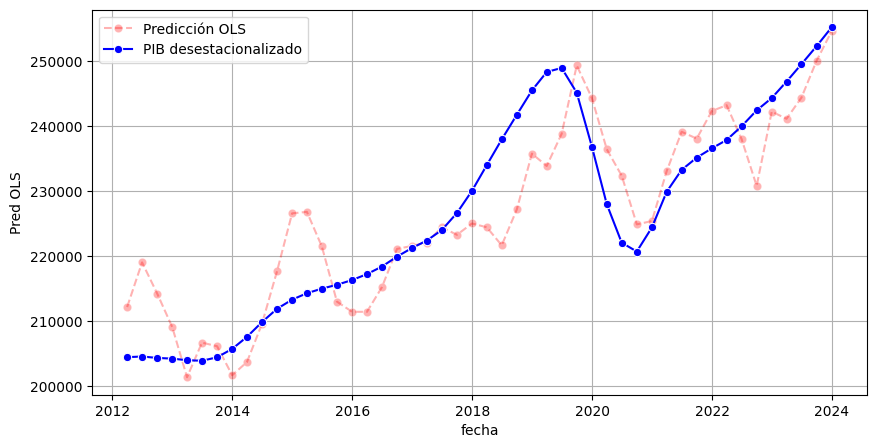

In [80]:
# Añadir una constante al modelo
X = mont_rad_pib.drop(columns = ["quarter", "fecha", "pib_mun_desestacionalizado", "municipio", "pib_mun"])
y = mont_rad_pib["pib_mun"]

X = sm.add_constant(X)
modelo = sm.OLS(y, X)
resultado = modelo.fit()

print(resultado.summary())

mont_rad_pib["Pred OLS"] = resultado.predict(X)

plt.figure(figsize=(10, 5))
sns.lineplot(x="fecha", y="Pred OLS", data=mont_rad_pib, color = "red", label = "Predicción OLS", marker = "o", linestyle = "--", alpha = 0.3)
sns.lineplot(x="fecha", y="pib_mun", data=mont_rad_pib, color = "blue", label = "PIB desestacionalizado", marker = "o")
plt.legend()
plt.grid(True)
plt.show()

